In [1]:
import torch
from PIL import Image

In [2]:
import html
import matplotlib
from matplotlib.colors import Normalize, to_hex
from IPython.display import HTML

def colorize(tokens:list[str], weights:list[float], target:str=None):
    """returns a html heatmap representation of the tokens colored by weights.
        tokens and weights should match in lenghth
        target is optionally the token the weights were calculated for
    """
    template = '<span style="color: black; background-color: {}">{}</span>'
    colors = map(to_hex, matplotlib.colormaps['bwr'](Normalize(vmin=-1, vmax=1)(weights)))
    colored_output = ''
    for token, color in zip(tokens, colors):
        colored_output += template.format(color, '&nbsp'+html.escape(token)+'&nbsp')
    if target:
        colored_output += template.format('lime', '&nbsp'+html.escape(target)+'&nbsp')
    return HTML(colored_output)

## Hacky FRCNN data loading

In [3]:
# make HF dataset from faster-RCNN bounding box features
from datasets import ClassLabel, Value, Array2D, Array3D, Sequence
from datasets import load_dataset
import csv, sys
csv.field_size_limit(sys.maxsize)
import base64
import numpy as np

def base64_decode(value):
    return np.frombuffer(base64.b64decode(value), dtype=np.int64).tobytes()

dataset_frcnn = load_dataset('csv', 
                             data_files={'val': '/datasets/public/mscoco_frcnn/val2014_obj36.tsv'},
                             delimiter='\t',
                             column_names=['img_id', 'img_h', 'img_w', 'objects_id', 'objects_conf','attrs_id', 'attrs_conf', 'num_boxes', 'boxes', 'features'],
                             index_col=0,
                             nrows=1,
                             converters={'objects_id': base64.b64decode, 'objects_conf': base64.b64decode, 'attrs_id': base64.b64decode, 'attrs_conf': base64.b64decode, 'boxes': base64.b64decode, 'features': base64.b64decode},
                            )

dataset_frcnn['val'].features

/scratch/koegel/.conda-envs/playground/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Generating val split: 1 examples [00:00, 28.79 examples/s]


{'img_h': Value('int64'),
 'img_w': Value('int64'),
 'objects_id': Value('binary'),
 'objects_conf': Value('binary'),
 'attrs_id': Value('binary'),
 'attrs_conf': Value('binary'),
 'num_boxes': Value('int64'),
 'boxes': Value('binary'),
 'features': Value('binary'),
 'img_id': Value('string')}

## Query LXMERT

In [25]:
bbox_feats = torch.frombuffer(dataset_frcnn['val'][0]['features'], dtype=torch.float32).reshape((1, dataset_frcnn['val'][0]['num_boxes'], -1))

In [26]:
boxes = torch.frombuffer(dataset_frcnn['val'][0]['boxes'], dtype=torch.float32).reshape((1, dataset_frcnn['val'][0]['num_boxes'], 4))
normalized_boxes = boxes.clone()
normalized_boxes[..., (0, 2)] /= dataset_frcnn['val'][0]['img_w']
normalized_boxes[..., (1, 3)] /= dataset_frcnn['val'][0]['img_h']

In [28]:
# Load LXMERT from HF
import requests
from transformers import LxmertTokenizer, LxmertForQuestionAnswering, LxmertConfig

config = LxmertConfig.from_pretrained("unc-nlp/lxmert-vqa-uncased")

# get the class id to answer label mapping (lxmert is an old model which still had it separate)
label2ans = requests.get('https://raw.githubusercontent.com/airsplay/lxmert/refs/heads/master/data/vqa/trainval_label2ans.json').json()
config.id2label = {int(k): v for k, v in enumerate(label2ans)}
config.label2id = {v: k for k, v in id2label.items()}

tokenizer = LxmertTokenizer.from_pretrained("unc-nlp/lxmert-vqa-uncased")
model = LxmertForQuestionAnswering.from_pretrained("unc-nlp/lxmert-vqa-uncased", config=config)

In [29]:
question = "Where is the tv?"
text_inputs = tokenizer(question, return_tensors="pt")

In [30]:
outputs = model(**text_inputs,
                visual_feats=bbox_feats,
                visual_pos=normalized_boxes,
                return_dict=True,
                output_attentions=False,
               )

In [11]:
# for https://github.com/lutzroeder/netron
# exported_model = torch.export.export(model, (), kwargs={**text_inputs, 'visual_feats': bbox_feats, 'visual_pos': normalized_boxes})
# torch.export.save(exported_model, "model.pt")

In [33]:
model.config.id2label[outputs.question_answering_score.argmax().item()]

'against wall'

In [35]:
input_ids = tokenizer(question, return_tensors="pt").input_ids
input_embeds = model.get_input_embeddings()(input_ids).detach()
outputs = model(inputs_embeds=input_embeds.requires_grad_(),
                visual_feats=bbox_feats.requires_grad_(),
                visual_pos=normalized_boxes,
                return_dict=True,
                #output_attentions=False,
               )

#max_logit, target_index = outputs['question_answering_score'].max(-1)
#max_logit.backward(max_logit)

target_index = model.config.label2id['yellow']
alternative_logit = outputs['question_answering_score'][0, target_index]
alternative_logit.backward(alternative_logit)

In [36]:
# the composite replaced the gradient backward functions by relevance rules
# thus the .grad attribute contains the relevance of input embedding elements wrt. next token prediction
# we sum over all elements of the embedding to get the relevance of the full embedding
text_relevance = input_embeds.grad.float().sum(-1).cpu()[0]
img_relevance = bbox_feats.grad.float().sum(-1).cpu()[0]
total_relevance = torch.concat([text_relevance, img_relevance])

# normalize relevance between [-1, 1]
text_relevance = text_relevance / text_relevance.abs().max()
img_relevance = img_relevance / img_relevance.abs().max()
#text_relevance = text_relevance / total_relevance.abs().max()
#img_relevance = img_relevance / total_relevance.abs().max()

print(text_relevance)
print(img_relevance)

tensor([-0.1250,  0.0833,  0.0152,  0.0379, -1.0000,  0.0227,  0.1212])
tensor([ 0.8400, -0.7823, -0.0574, -0.4315,  0.8346, -0.3416,  0.2216,  0.2570,
        -0.2837, -0.3555,  0.3003,  0.4876,  0.4350, -0.4911, -0.5184,  0.8308,
         0.7757, -0.2772, -0.1557, -0.1279,  0.2629,  0.1782, -0.5103, -0.1499,
        -0.4825, -0.7575,  0.4785, -0.3521, -0.7082,  0.5113, -1.0000,  0.0120,
        -0.0938,  0.0284, -0.4836,  0.6888])


## Compute Relevance

In [40]:
from lxt.explicit.tools import traced_backward

In [38]:
# load adapted LXMERT model and rule composite from attnLRP
from lxt.explicit.models.lxmert import LxmertForQuestionAnswering, attnlrp as lrp_rule_composite

# still use original weights checkpoint from huggingface (from_pretrained)
adapted_model = LxmertForQuestionAnswering.from_pretrained("unc-nlp/lxmert-vqa-uncased", config=config)

# there is multiple ways to modify the model to compute relevance
# part of the model was directly modified in code, part can be handled by automatic lrp rules, which we now apply
lrp_rule_composite.register(adapted_model);

In [39]:
question = "Which color has the banana?"
text_inputs = tokenizer(question, return_tensors="pt")

In [22]:
input_ids = tokenizer(question, return_tensors="pt").input_ids
input_embeds = adapted_model.get_input_embeddings()(input_ids)
bbox_feats.grad = None
normalized_boxes.grad = None
outputs = adapted_model(inputs_embeds=input_embeds.requires_grad_(),
                visual_feats=bbox_feats.requires_grad_(),
                visual_pos=normalized_boxes.requires_grad_(),
                return_dict=True,
                #output_attentions=False,
               )

max_logit, target_index = outputs['question_answering_score'].max(-1)
#max_logit.backward(max_logit) #, retain_graph=True)

# target_index = vqa_trainval2ans.index('yellow')
# alternative_logit = outputs['question_answering_score'][0, target_index]
# alternative_logit.backward(alternative_logit)

# hook.remove()
# hook2.remove()

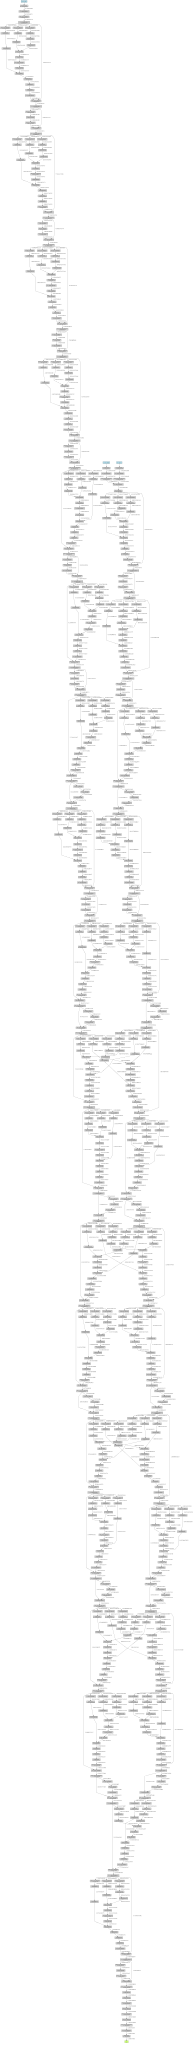

In [23]:
make_dot(max_logit, params=dict(adapted_model.named_parameters()), show_attrs=False, show_saved=False)

Under conservation check the correct total relevance is achieved, but without the relevance increases due to (negative) relevance absorbed by biases, position embeddings etc

In [24]:
# the composite replaced the gradient backward functions by relevance rules
# thus the .grad attribute contains the relevance of input embedding elements wrt. next token prediction
# we sum over all elements of the embedding to get the relevance of the full embedding
text_relevance = input_embeds.grad.float().sum(-1).cpu()[0]
img_relevance = bbox_feats.grad.float().sum(-1).cpu()[0]
pos_relevance = normalized_boxes.grad.float().sum(-1).cpu()[0]
total_relevance = torch.concat([text_relevance, img_relevance, pos_relevance])

# normalize relevance between [-1, 1]
# text_relevance = text_relevance / text_relevance.abs().max()
# img_relevance = img_relevance / img_relevance.abs().max()
# pos_relevance = pos_relevance / pos_relevance.abs().max()

text_relevance = text_relevance / total_relevance.abs().max()
img_relevance = img_relevance / total_relevance.abs().max()
pos_relevance = pos_relevance / total_relevance.abs().max()

print(total_relevance.sum()) # not entirely true because it does not consider all the (negative) relevance absorbed by other inputs/position embeddings/biases
print(text_relevance.sum())
print(img_relevance.sum())
print(pos_relevance.sum())
max_logit

tensor(88.3656)
tensor(1.3622)
tensor(0.0680)
tensor(-0.0263)


tensor([12.5106], grad_fn=<MaxBackward0>)

In [25]:
colorize(tokens=tokenizer.batch_decode(input_ids[0]), weights=text_relevance, target=vqa_trainval2ans[target_index])

In [147]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

img_relevance_map = torch.zeros((dataset_frcnn['val'][0]['img_h'], dataset_frcnn['val'][0]['img_w']))
for (x1, y1, x2, y2), relevance in zip(boxes[0], img_relevance):
    img_relevance_map[int(y1):int(y2), int(x1):int(x2)] += relevance
# we should probably not re-normalize here, but for viz it's ok
img_relevance_map /= img_relevance_map.abs().max()

plt.imshow(Image.open('COCO_val2014_000000568281.jpg'))
plt.imshow(img_relevance_map, cmap='bwr', vmin=-1, vmax=1, alpha=0.5)

colors = map(to_hex, matplotlib.colormaps['bwr'](Normalize(vmin=-1, vmax=1)(pos_relevance)))
for (x1, y1, x2, y2), color in zip(boxes[0], colors):
    plt.gca().add_patch(Rectangle((x1,y1),x2-x1,y2-y1,linewidth=1,edgecolor=color, facecolor='none'))

RuntimeError: The size of tensor a (182) must match the size of tensor b (1067) at non-singleton dimension 1

### FRCNN

In [148]:
import modeling_frcnn
importlib.reload(modeling_frcnn)
import lxt.explicit.functional
importlib.reload(lxt.explicit.functional)

<module 'lxt.explicit.functional' from '/scratch/koegel/relevance_dissipation/lxt/lxt/explicit/functional.py'>

In [149]:
# load frcnn
from modeling_frcnn import GeneralizedRCNN
import utils as utils
from processing_image import Preprocess

frcnn_cfg = utils.Config.from_pretrained("unc-nlp/frcnn-vg-finetuned")
frcnn = GeneralizedRCNN.from_pretrained("unc-nlp/frcnn-vg-finetuned", config=frcnn_cfg).to('cuda')
image_preprocess = Preprocess(frcnn_cfg)

loading configuration file cache
loading weights file https://cdn.huggingface.co/unc-nlp/frcnn-vg-finetuned/pytorch_model.bin from cache at /home/koegel/.cache/torch/transformers/57f6df6abe353be2773f2700159c65615babf39ab5b48114d2b49267672ae10f.77b59256a4cf8343ae0f923246a81489fc8d82f98d082edc2d2037c977c0d9d0
All model checkpoint weights were used when initializing GeneralizedRCNN.

All the weights of GeneralizedRCNN were initialized from the model checkpoint at unc-nlp/frcnn-vg-finetuned.
If your task is similar to the task the model of the checkpoint was trained on, you can already use GeneralizedRCNN for predictions without further training.


In [150]:
from zennit.composites import EpsilonGammaBox

composite = EpsilonGammaBox(-255, 255)
composite.register(frcnn)

In [139]:
# import lxt.explicit.rules as rules
# from lxt.explicit.core import Composite
# from zennit.composites import LayerMapComposite
# import zennit.rules as z_rules
# import torch.nn as nn

# attnlrp = Composite(
#     {        
#         nn.ReLU: rules.IdentityRule,
#     },
#     zennit_composite=LayerMapComposite([
#         (nn.Conv2d, z_rules.Gamma(100)),
#         (nn.Linear, z_rules.Gamma(0.05)),
#     ])
# )

In [151]:
import torch.nn as nn
class LxmertFullModel(nn.Module):
    def __init__(self):
        super(LxmertFullModel, self).__init__()
        self.frcnn = frcnn
        self.lxmert = adapted_model

        # Deactivate gradients on parameters to save memory
        for p in self.parameters():
            p.requires_grad = False

    def forward(self, images, sizes, scales_yx, input_embeds):
        output_dict = self.frcnn(
            images,
            sizes,
            scales_yx=scales_yx,
            padding="max_detections",
            max_detections= frcnn_cfg.max_detections,
            return_tensors="pt",
        )

        norm_boxes = output_dict.get("normalized_boxes")
        features = output_dict.get("roi_features")

        #return norm_boxes, features

        outputs = self.lxmert(inputs_embeds=input_embeds,
                        visual_feats=features,
                        visual_pos=norm_boxes,
                        return_dict=True,
                        #output_attentions=False,
                       )
        return outputs

In [152]:
full_model = LxmertFullModel()

In [153]:
question = "Where is the TV, left or right?" #"Which color has the banana?"
text_inputs = tokenizer(question, return_tensors="pt")

In [104]:
# from lxt.explicit.functional import CONSERVATION_CHECK_FLAG
# CONSERVATION_CHECK_FLAG[0] = True

# images, sizes, scales_yx = image_preprocess('COCO_val2014_000000568281.jpg')
# input_ids = tokenizer(question, return_tensors="pt").input_ids
# input_embeds = adapted_model.get_input_embeddings()(input_ids)

# norm_boxes, features = full_model(images.cuda().requires_grad_(), sizes, scales_yx, input_embeds.requires_grad_())

In [105]:
# dummy = torch.concat((features.flatten(), norm_boxes.flatten()))
# make_dot(dummy.sum()/dummy.sum().detach(), params=dict(full_model.frcnn.named_parameters()), show_attrs=False, show_saved=False).render(filename='gprah.pdf')

In [106]:
# for hook in scope_hooks:
#     hook.remove()
# scope_hooks = []
# scope = []
# def scope_hook(module, input, output):
#     scope.append(output[0])
# scope_hooks.append(full_model.frcnn.roi_outputs.register_forward_hook(scope_hook))

In [107]:
# try: 
#     hook1.remove()
# except: 
#     pass
# save = []
# hook1 = full_model.frcnn.roi_heads.res5[2].conv3.register_backward_hook(lambda m, i, o: save.append([i, o]))

In [154]:
from lxt.explicit.functional import CONSERVATION_CHECK_FLAG
CONSERVATION_CHECK_FLAG[0] = False

images, sizes, scales_yx = image_preprocess('COCO_val2014_000000568281.jpg')
images = images.cuda()
input_ids = tokenizer(question, return_tensors="pt").input_ids
input_embeds = adapted_model.get_input_embeddings()(input_ids)

outputs = full_model(images.requires_grad_(), sizes, scales_yx, input_embeds.requires_grad_())

max_logit, target_index = outputs['question_answering_score'].max(-1)
max_logit.backward(max_logit) #, retain_graph=True)

In [116]:
#make_dot(max_logit, params=dict(full_model.named_parameters()), show_attrs=False, show_saved=False).render('output.pdf')

edge <CatBackward0 object at 0x782aadb2b2b0> <CppFunction object at 0x782aadb2b0d0> 1
node <CatBackward0 object at 0x782aadb2b2b0> CatBackward0
edge <CatBackward0 object at 0x782aadb3c670> <CatBackward0 object at 0x782aadb2b2b0> 0
node <CatBackward0 object at 0x782aadb3c670> CatBackward0
edge <IndexBackward0 object at 0x782aadb3e200> <CatBackward0 object at 0x782aadb3c670> 1


'output.pdf.pdf'

In [155]:
# the composite replaced the gradient backward functions by relevance rules
# thus the .grad attribute contains the relevance of input embedding elements wrt. next token prediction
# we sum over all elements of the embedding to get the relevance of the full embedding
text_relevance = input_embeds.grad.float().sum(-1).cpu()[0]
img_relevance = images.grad[0].float().sum(0).cpu()
total_relevance = torch.concat([text_relevance, img_relevance.flatten()])

print(text_relevance.sum())#, text_relevance)
print(img_relevance.sum())#, img_relevance)

# normalize relevance between [-1, 1]
text_relevance = text_relevance / text_relevance.abs().max()
img_relevance = img_relevance / img_relevance.abs().max()

# text_relevance = text_relevance / total_relevance.abs().max()
# img_relevance = img_relevance / total_relevance.abs().max()

tensor(87.7133)
tensor(1.6697e+09)


In [156]:
colorize(tokens=tokenizer.batch_decode(input_ids[0]), weights=text_relevance, target=vqa_trainval2ans[target_index])

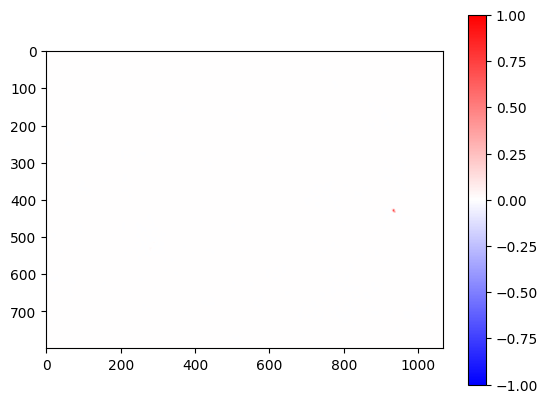

In [157]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

#plt.imshow(Image.open('COCO_val2014_000000568281.jpg').resize(sizes[0].flip(0), Image.BILINEAR))
plt.imshow(img_relevance, cmap='bwr', vmin=-1, vmax=1)
plt.colorbar()

## Only FRCNN relevance

In [158]:
images, sizes, scales_yx = image_preprocess('COCO_val2014_000000568281.jpg')
images = images.cuda()

In [159]:
output_dict = frcnn(images.requires_grad_(), sizes, scales_yx=scales_yx, padding="max_detections", max_detections= frcnn_cfg.max_detections, return_tensors="pt")

norm_boxes = output_dict.get("normalized_boxes")
features = output_dict.get("roi_features")

In [160]:
idx = 10
pos = norm_boxes[0][idx]
pos.backward(pos, retain_graph=True)

img_relevance = images.grad[0].float().sum(0).cpu()
# normalize relevance between [-1, 1]
img_relevance = img_relevance / img_relevance.abs().max()

plt.title(f'img relevance for bbox position of feature {idx}')
plt.imshow(img_relevance, cmap='bwr', vmin=-1, vmax=1)
plt.colorbar()

OutOfMemoryError: CUDA out of memory. Tried to allocate 188.00 MiB. GPU 0 has a total capacity of 31.73 GiB of which 4.44 MiB is free. Including non-PyTorch memory, this process has 31.72 GiB memory in use. Of the allocated memory 30.57 GiB is allocated by PyTorch, and 796.96 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

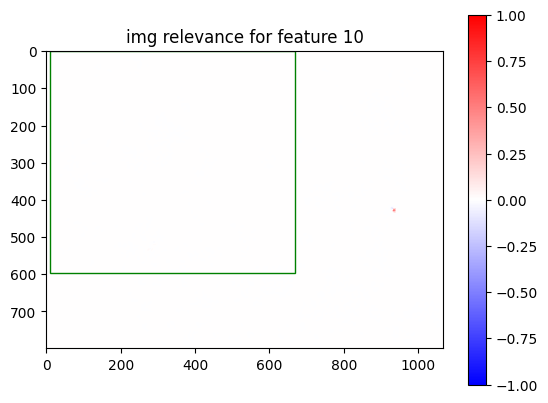

In [92]:
feat = features[0][idx]
feat.backward(feat)

img_relevance = images.grad[0].float().sum(0).cpu()
# normalize relevance between [-1, 1]
img_relevance = img_relevance / img_relevance.abs().max()

plt.title(f'img relevance for feature {idx}')
plt.imshow(img_relevance, cmap='bwr', vmin=-1, vmax=1)
plt.colorbar()
box = norm_boxes[0][idx].detach() 
box[..., (0, 2)] *= sizes[0][0]
box[..., (1, 3)] *= sizes[0][1]
x1, y1, x2, y2 = box
plt.gca().add_patch(Rectangle((x1,y1), x2-x1, y2-y1, linewidth=1, edgecolor='green',  facecolor='none'))

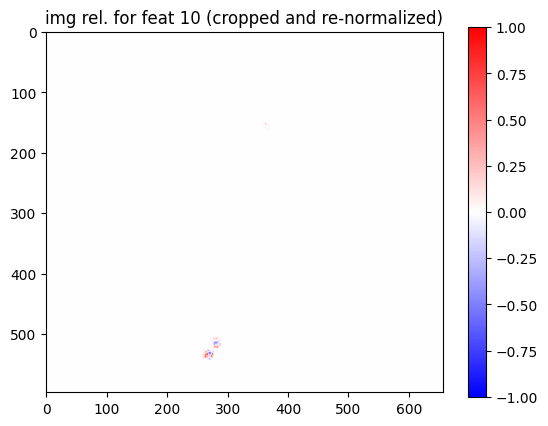

In [95]:
feat_img_relevance = img_relevance[int(y1):int(y2), int(x1):int(x2)]
feat_img_relevance = feat_img_relevance / feat_img_relevance.abs().max()
plt.title(f'img rel. for feat {idx} (cropped and re-normalized)')
plt.imshow(feat_img_relevance, cmap='bwr', vmin=-1, vmax=1)
plt.colorbar()